# 07 — Full EDA

**Purpose:** Analyse all EnFa subsystems using the hourly Parquet from notebook 06.

**Requires:** `data/processed/hourly.parquet`
Run notebook 06 first if it does not exist.

**Sections:**
1. Energy overview — grid, PV, HP monthly balance
2. Heat pump COP — first customer deliverable
3. Battery — SOC and cycling
4. Controls — night setback patterns
5. Correlations — cross-system heatmap

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from zoro_eda.config import load_config
from zoro_eda.paths import resolve_paths

cfg   = load_config()
paths = resolve_paths(cfg=cfg)

pq_path = paths.processed / "hourly.parquet"
if not pq_path.exists():
    raise FileNotFoundError(f"Run notebook 06 first: {pq_path}")

df = pd.read_parquet(pq_path)
print(f"Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Range  : {df.index.min()}  →  {df.index.max()}")

# Localise to Europe/Berlin for daily/seasonal plots
df_local = df.copy()
df_local.index = df_local.index.tz_convert("Europe/Berlin")

sns.set_theme(style="whitegrid", palette="tab10")
plots_dir = paths.reports / "plots"
plots_dir.mkdir(exist_ok=True)
print("Ready.")

Loaded : 29,207 rows × 215 columns
Range  : 2022-11-30 10:00:00+00:00  →  2026-05-27 07:00:00+00:00
Ready.


## Section 1: Energy overview

Monthly energy balance across the main meters.
Signals used (all delta-aggregated → kWh per hour, summed to monthly):
- `greal_E_WP` — heat pump electricity consumption
- `greal_E_PV` — PV generation (if present)
- `greal_E_Netz` or similar — grid import/export

In [2]:
# Identify available energy signals
energy_cols = [c for c in df.columns if c.startswith("greal_E_") or
               any(k in c.lower() for k in ("netz","pv","bhkw","wp")) and "greal_E" in c]
print("Energy-related columns found:")
for c in energy_cols[:20]:
    print(f"  {c}  min={df[c].min():.1f}  max={df[c].max():.1f}")

Energy-related columns found:
  greal_E__WMZ_BHKW  min=0.0  max=349.6
  greal_E__WMZ_WWout  min=0.0  max=476.8
  greal_E_BatterieAbgabe  min=0.0  max=7283.8
  greal_E_BatterieLaden  min=0.0  max=9153.4
  greal_E_bhkw1  min=0.0  max=219987192737584407441171083539056164864.0
  greal_E_bhkw2  min=0.0  max=7157.6
  greal_E_ErzeugungEnFa  min=0.0  max=71800.3
  greal_E_Gebaeude  min=0.0  max=18690.6
  greal_E_GebaeudeNord  min=0.0  max=8632.4
  greal_E_GebaeudeSued  min=0.0  max=10058.2
  greal_E_GebaeudeSystem  min=0.0  max=0.0
  greal_E_Gesamtverbrauch  min=0.0  max=20787.7
  greal_E_PV1  min=0.0  max=4849.9
  greal_E_PV2  min=0.0  max=5559.3
  greal_E_PV3  min=0.0  max=4428.7
  greal_E_PV4  min=0.0  max=8065.7
  greal_E_PV5  min=0.0  max=11390.7
  greal_E_PV6  min=0.0  max=12115.3
  greal_E_PV7  min=0.0  max=11134.3
  greal_E_PV_Gesamt  min=0.0  max=55538.2


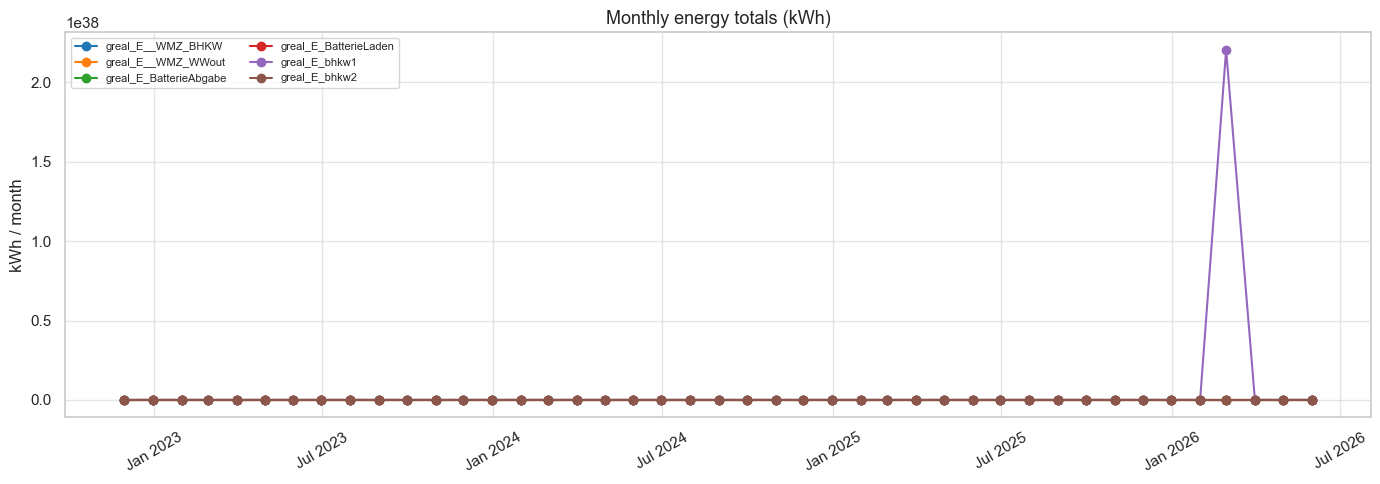

In [3]:
# Build monthly sums for whichever energy columns exist
monthly = df.resample("ME").sum()

# Plot top energy signals monthly
plot_cols = [c for c in energy_cols if c in monthly.columns][:6]
if not plot_cols:
    print("No energy columns found — check column names above")
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    for col in plot_cols:
        ax.plot(monthly.index, monthly[col], marker="o", label=col, linewidth=1.5)
    ax.set_title("Monthly energy totals (kWh)", fontsize=13)
    ax.set_ylabel("kWh / month")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.legend(fontsize=8, ncol=2)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(plots_dir / "07_energy_overview.png", dpi=150, bbox_inches="tight")
    plt.show()

## Section 2: Heat pump COP — customer deliverable

COP (Coefficient of Performance) = thermal energy out / electrical energy in.

We use delta-aggregated hourly signals:
- Thermal output: `greal_WMZ_Hz_Erz_WP` (heat meter, kWh)
- Electrical input: `greal_E_WP` (energy meter, kWh)

Daily COP is more stable than hourly (avoids division noise during short cycles).

In [4]:
# Identify HP thermal and electrical signals
thermal_candidates = [c for c in df.columns if "WMZ" in c and "WP" in c]
elec_candidates    = [c for c in df.columns if c in ("greal_E_WP",) or
                      ("E_WP" in c and "greal" in c)]
print("Thermal candidates:", thermal_candidates)
print("Electrical candidates:", elec_candidates)

Thermal candidates: ['greal_K_WMZ_E_WP', 'greal_K_WMZ_P_WP', 'greal_W_WMZ_E_WP', 'greal_W_WMZ_P_WP', 'greal_W_WMZ_TR_WP', 'greal_W_WMZ_TV_WP', 'greal_WMZ_Hz_Erz_WP', 'greal_WMZ_Kalt_Erz_WP']
Electrical candidates: ['greal_E_WP', 'greal_K_WMZ_E_WP', 'greal_W_WMZ_E_WP']


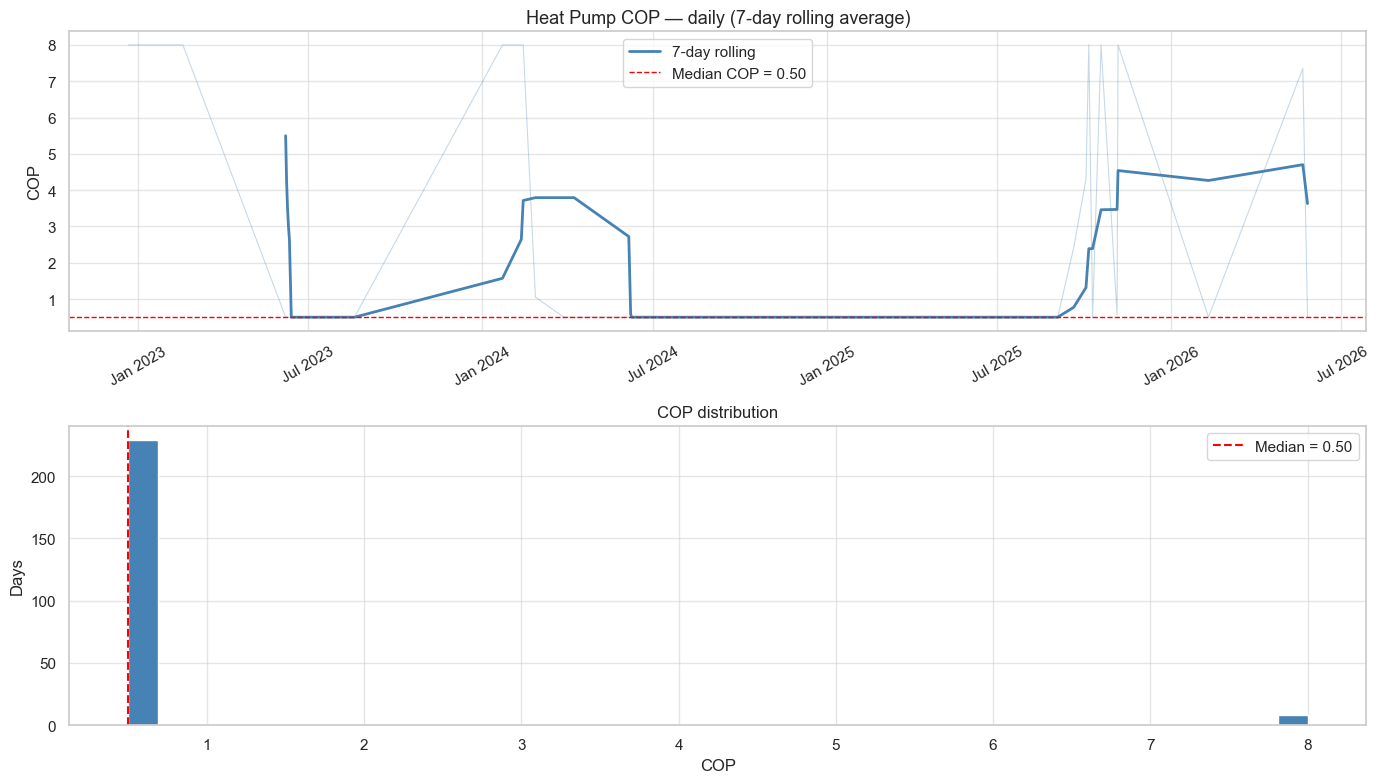

Median COP  : 0.50
Mean COP    : 0.80
Days with data: 241


In [5]:
# COP calculation — adjust column names if the auto-detection above shows different names
THERMAL_COL = thermal_candidates[0] if thermal_candidates else None
ELEC_COL    = elec_candidates[0]    if elec_candidates    else None

if not THERMAL_COL or not ELEC_COL:
    print("Could not find HP thermal or electrical columns — check candidates above")
else:
    daily  = df[[THERMAL_COL, ELEC_COL]].resample("D").sum()
    daily  = daily[(daily[ELEC_COL] > 0.1) & (daily[THERMAL_COL] > 0.1)]
    daily["cop"] = (daily[THERMAL_COL] / daily[ELEC_COL]).clip(0.5, 8)

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    # COP time series (7-day rolling)
    roll = daily["cop"].rolling(7, min_periods=3).mean()
    axes[0].plot(daily.index, daily["cop"], alpha=0.3, color="steelblue", linewidth=0.8)
    axes[0].plot(roll.index,  roll,         color="steelblue", linewidth=2, label="7-day rolling")
    axes[0].axhline(daily["cop"].median(), color="red", linestyle="--",
                    linewidth=1, label=f"Median COP = {daily['cop'].median():.2f}")
    axes[0].set_title("Heat Pump COP — daily (7-day rolling average)", fontsize=13)
    axes[0].set_ylabel("COP")
    axes[0].legend()
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(axes[0].get_xticklabels(), rotation=30)

    # COP histogram
    axes[1].hist(daily["cop"].dropna(), bins=40, color="steelblue", edgecolor="white")
    axes[1].axvline(daily["cop"].median(), color="red", linestyle="--",
                    label=f"Median = {daily['cop'].median():.2f}")
    axes[1].set_title("COP distribution", fontsize=12)
    axes[1].set_xlabel("COP")
    axes[1].set_ylabel("Days")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(plots_dir / "07_hp_cop.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Median COP  : {daily['cop'].median():.2f}")
    print(f"Mean COP    : {daily['cop'].mean():.2f}")
    print(f"Days with data: {len(daily)}")

## Section 3: Battery SOC and cycling

Battery state of charge over the full period.
Cycling depth = how much the SOC swings each day (max - min).
Deep daily cycling shortens battery life.

SOC columns found: ['greal_BatterieLadeZustand']


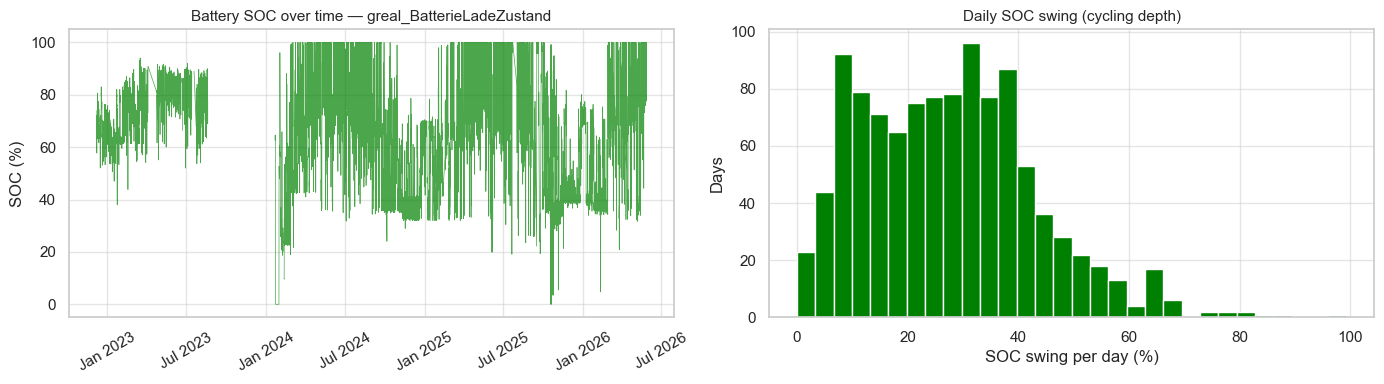

Median daily swing: 26.8%


In [6]:
soc_cols = [c for c in df.columns if "ladezustand" in c.lower() or "soc" in c.lower()
            or ("ladezu" in c.lower())]
print("SOC columns found:", soc_cols)

if soc_cols:
    soc_col = soc_cols[0]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(df.index, df[soc_col], linewidth=0.5, color="green", alpha=0.7)
    axes[0].set_title(f"Battery SOC over time — {soc_col}", fontsize=11)
    axes[0].set_ylabel("SOC (%)")
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(axes[0].get_xticklabels(), rotation=30)

    daily_soc = df[soc_col].resample("D").agg(["min","max"])
    daily_soc["swing"] = daily_soc["max"] - daily_soc["min"]
    axes[1].hist(daily_soc["swing"].dropna(), bins=30, color="green", edgecolor="white")
    axes[1].set_title("Daily SOC swing (cycling depth)", fontsize=11)
    axes[1].set_xlabel("SOC swing per day (%)")
    axes[1].set_ylabel("Days")

    plt.tight_layout()
    plt.savefig(plots_dir / "07_battery_soc.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Median daily swing: {daily_soc['swing'].median():.1f}%")

## Section 4: Controls — night setback patterns

Night setback = heating setpoints are lowered during unoccupied hours.
This heatmap shows the average setpoint value by hour-of-day and month,
revealing occupancy patterns and seasonal control schedules.

Night setback columns: ['greal_Nachtabsenkung', 'V_real_Nachtabsenkung', 'V_real_NachtabsenkungY4']
V_real setpoint columns: 21


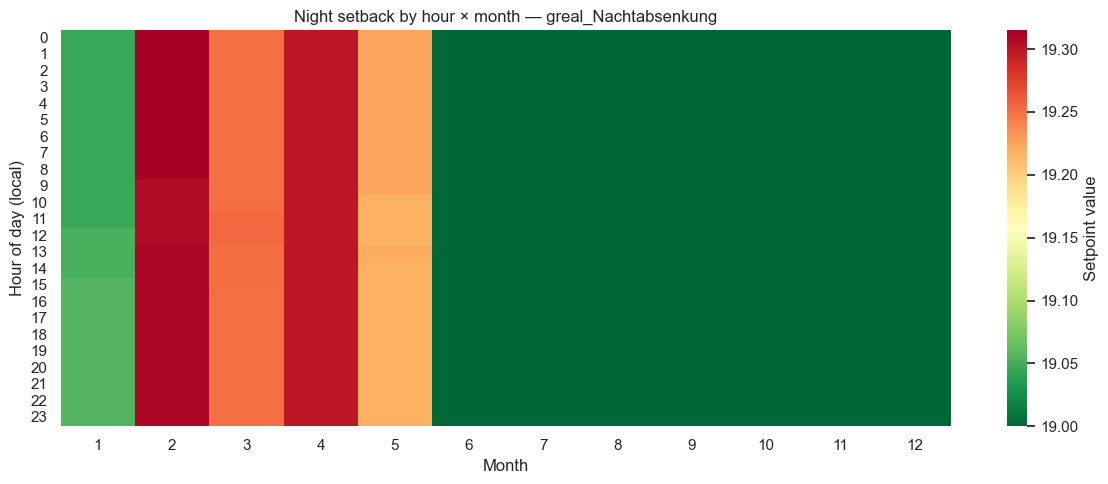

In [7]:
setback_cols = [c for c in df.columns if "nacht" in c.lower() or
                "setback" in c.lower() or "absenkung" in c.lower()]
setpoint_cols_all = [c for c in df.columns if c.startswith("V_real")]

print("Night setback columns:", setback_cols)
print(f"V_real setpoint columns: {len(setpoint_cols_all)}")

if setback_cols:
    sb_col = setback_cols[0]
    pivot  = df_local.groupby([df_local.index.hour, df_local.index.month])[sb_col].mean().unstack()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn_r", cbar_kws={"label": "Setpoint value"})
    ax.set_title(f"Night setback by hour × month — {sb_col}", fontsize=12)
    ax.set_xlabel("Month")
    ax.set_ylabel("Hour of day (local)")
    plt.tight_layout()
    plt.savefig(plots_dir / "07_night_setback_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No night setback columns found — check V_real signals above")

## Section 5: Cross-system correlation heatmap

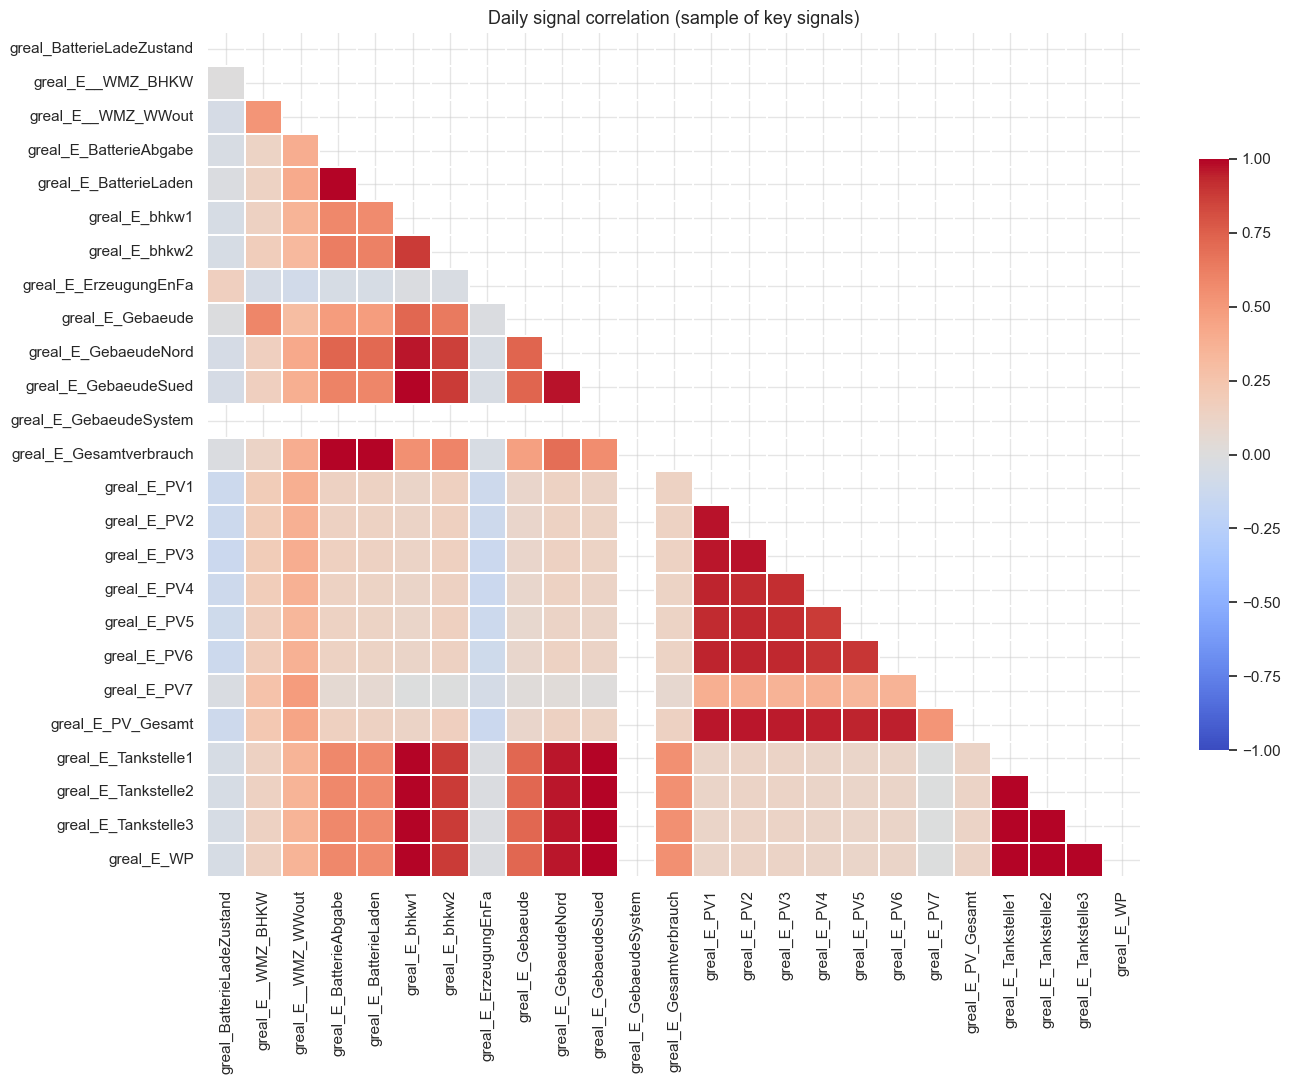

In [8]:
# Select a representative set of signals for correlation
candidate_prefixes = ("greal_E_", "greal_WMZ_", "greal_Batterie", "real_Batterie",
                      "real_AT", "greal_WP")
rep_cols = [c for c in df.columns
            if any(c.startswith(p) for p in candidate_prefixes)][:25]

if len(rep_cols) < 3:
    print("Too few candidate columns — listing all columns for manual selection:")
    print(df.columns.tolist()[:30])
else:
    daily_df = df[rep_cols].resample("D").mean().dropna(thresh=len(rep_cols)//2)
    corr = daily_df.corr()

    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(14, 11))
    sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
                vmin=-1, vmax=1, annot=len(rep_cols) <= 15,
                fmt=".2f", linewidths=0.3, cbar_kws={"shrink": 0.7})
    ax.set_title("Daily signal correlation (sample of key signals)", fontsize=13)
    plt.tight_layout()
    plt.savefig(plots_dir / "07_correlation_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()

## Key findings

After running this notebook:
- HP COP chart (`reports/plots/07_hp_cop.png`) is the first customer deliverable
- Battery cycling depth indicates whether the current control strategy is aggressive
- Night setback heatmap reveals actual occupancy schedule vs design intent
- Correlation heatmap shows which signals move together — useful for MPC feature selection

**Next notebooks:**
- `08_hp_model.ipynb` — physics-based HP COP model (COP vs outdoor temp)
- `09_battery_model.ipynb` — round-trip efficiency, degradation
- `10_mpc_prototype.ipynb` — MPC state-space formulation